In [1]:
import os

import matplotlib.pyplot as plt
import sinter

from qecdec.experiments import RotatedSurfaceCode_Memory

In [2]:
def generate_sinter_tasks():
    tasks: list[sinter.Task] = []
    for d in [5, 7, 9, 11]:
        for p in [0.01, 0.02, 0.03, 0.04, 0.05]:
            # Setup the experiment.
            expmt_d_rounds = RotatedSurfaceCode_Memory(
                d=d,
                rounds=d,
                basis="Z",
                data_qubit_error_rate=p,
                meas_error_rate=p,
            )

            # Setup a sinter.Task with MWPM decoder.
            tasks.append(
                sinter.Task(
                    circuit=expmt_d_rounds.circuit,
                    detector_error_model=expmt_d_rounds.dem,
                    decoder="pymatching",
                    json_metadata={"d": d, "p": p, "r": d, "group": "d_rounds"},
                )
            )
    return tasks


tasks = generate_sinter_tasks()

In [3]:
sinter_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    print_progress=False,
)

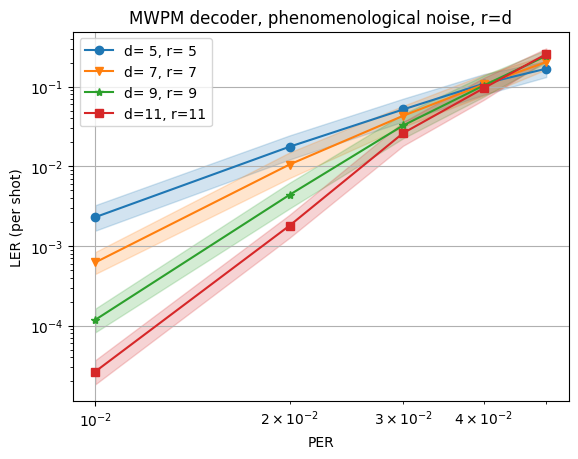

In [4]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    group_func=lambda stat: (
        f"d={stat.json_metadata['d']:2d}, r={stat.json_metadata['r']:2d}"
    ),
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per shot)")
ax.set_xlabel("PER")
ax.set_title("MWPM decoder, phenomenological noise, r=d")
ax.legend()

In [5]:
const_rounds = 1


def generate_sinter_tasks():
    tasks: list[sinter.Task] = []
    for d in [5, 7, 9, 11]:
        for p in [0.01, 0.02, 0.03, 0.04, 0.05]:
            # Setup the experiment.
            expmt_const_rounds = RotatedSurfaceCode_Memory(
                d=d,
                rounds=const_rounds,
                basis="Z",
                data_qubit_error_rate=p,
                meas_error_rate=p,
            )

            # Setup a sinter.Task with MWPM decoder.
            tasks.append(
                sinter.Task(
                    circuit=expmt_const_rounds.circuit,
                    detector_error_model=expmt_const_rounds.dem,
                    decoder="pymatching",
                    json_metadata={
                        "d": d,
                        "p": p,
                        "r": const_rounds,
                        "group": "const_rounds",
                    },
                )
            )
    return tasks


tasks = generate_sinter_tasks()

In [6]:
sinter_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    print_progress=False,
)

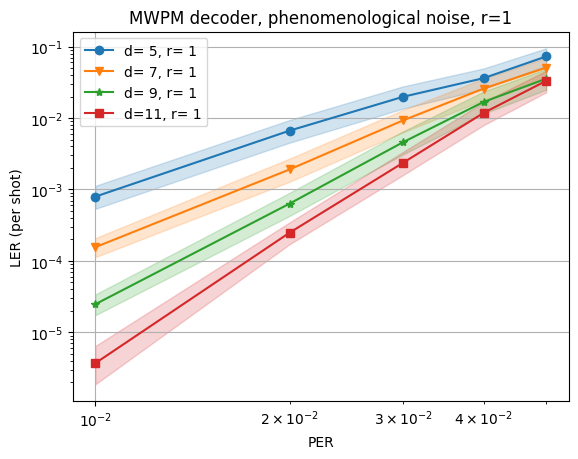

In [7]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    group_func=lambda stat: (
        f"d={stat.json_metadata['d']:2d}, r={stat.json_metadata['r']:2d}"
    ),
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per shot)")
ax.set_xlabel("PER")
ax.set_title(f"MWPM decoder, phenomenological noise, r={const_rounds}")
ax.legend()